In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import roc_auc_score,confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import OneHotEncoder

from data_process import process_raw_data, process_curated_data, data_encoding

In [2]:
df_raw = process_raw_data(yr_list = [2022,2023,2024])
df_cur = process_curated_data(df_raw = df_raw)
df_encoded = data_encoding(df_cur = df_cur)

### Starting data processing
    ## Processing data of 2022
    ## Processing data of 2023
    ## Processing data of 2024


/mnt/e/github/cartola-fc/data_process.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cur['year_season'] = df_cur['year'].astype("str") + "-" + df_cur['rodada_id'].astype("str")


In [4]:
cols_x = ["apelido","rodada_id","clube_id","preco_inicial","media_num","jogos_num","benefit_ratio","posicao_id_ata","posicao_id_gol","posicao_id_lat","posicao_id_mei","posicao_id_tec","posicao_id_zag"]
col_y = ["pontos_rodada_futura"]

df_ml = df_encoded[cols_x + col_y]
df_ml = df_ml.dropna()
df_ml[df_ml['apelido'] == 0]

,apelido,rodada_id,clube_id,preco_inicial,media_num,jogos_num,benefit_ratio,posicao_id_ata,posicao_id_gol,posicao_id_lat,posicao_id_mei,posicao_id_tec,posicao_id_zag,pontos_rodada_futura
0,0,19,6,13.73,6.00,19,0.566642,0.0,0.0,0.0,0.0,1.0,0.0,7.95
1,0,20,6,14.35,6.10,20,0.554007,0.0,0.0,0.0,0.0,1.0,0.0,7.45
2,0,21,6,14.47,6.16,21,0.514858,0.0,0.0,0.0,0.0,1.0,0.0,6.05
3,0,22,6,14.48,6.15,22,0.417818,0.0,0.0,0.0,0.0,1.0,0.0,7.35
4,0,23,6,14.47,6.20,23,0.507947,0.0,0.0,0.0,0.0,1.0,0.0,2.71
5,0,24,6,14.68,6.05,24,0.184605,0.0,0.0,0.0,0.0,1.0,0.0,4.29
6,0,25,6,14.06,5.98,25,0.305121,0.0,0.0,0.0,0.0,1.0,0.0,4.57
7,0,26,6,14.22,5.93,26,0.321378,0.0,0.0,0.0,0.0,1.0,0.0,2.20
8,0,27,6,14.24,5.79,27,0.154494,0.0,0.0,0.0,0.0,1.0,0.0,9.43
9,0,28,6,13.82,5.92,28,0.682344,0.0,0.0,0.0,0.0,1.0,0.0,12.09


In [5]:
X = df_ml[cols_x].values
y = df_ml[col_y].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

print(X)


[[  0.  19.   6. ...   0.   1.   0.]
 [  0.  20.   6. ...   0.   1.   0.]
 [  0.  21.   6. ...   0.   1.   0.]
 ...
 [688.   5.  14. ...   0.   0.   0.]
 [689.  10.  18. ...   1.   0.   0.]
 [689.  14.  18. ...   1.   0.   0.]]


In [6]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,  # Limite na profundidade para evitar overfitting
    min_samples_split=10,  # Exige mais amostras para criar um novo split
    min_samples_leaf=5,  # Exige que cada folha tenha pelo menos 5 amostras
    random_state=42
)
rf.fit(X_train,y_train)

/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [7]:
y_pred = rf.predict(X_test)
rf_score = rf.score(X_test,y_test)

print(f"Random Forest Score: {rf_score}")

Random Forest Score: 0.07814446719594992


In [8]:
cval_rf = cross_val_score(rf,X_train,y_train, cv=5)

print(f"Random Forest Cross Val Score {cval_rf}")

/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column

Random Forest Cross Val Score [0.05573056 0.0561528  0.07476922 0.06020174 0.03430295]


In [27]:
import pickle

# Nome do arquivo onde o modelo será salvo
model_filename = 'random_forest_model.pkl'

# Salvar o modelo
with open(model_filename, 'wb') as file:
    pickle.dump(rf, file)

print(f"Modelo salvo como {model_filename}")

Modelo salvo como random_forest_model.pkl


/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/tmp/ipykernel_9477/3159702915.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette="viridis")


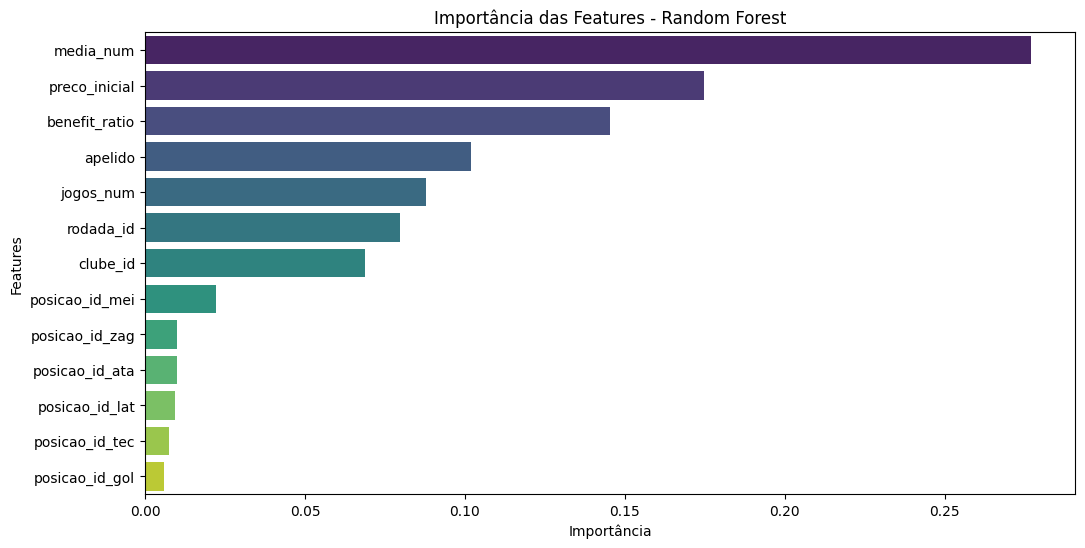

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Treinar o modelo (exemplo)
rf.fit(X_train, y_train)

# Obter importância das features
feature_importances = pd.DataFrame({
    'Feature': df_ml[cols_x].columns,
    'Importance': rf.feature_importances_
})

# Ordenar pela importância
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Criar o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette="viridis")

# Ajustes visuais
plt.xlabel("Importância")
plt.ylabel("Features")
plt.title("Importância das Features - Random Forest")
plt.show()


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1️⃣ Inicializar o modelo
lr = LinearRegression()

# 2️⃣ Treinar o modelo
lr.fit(X_train, y_train)

# 3️⃣ Fazer previsões
y_pred = lr.predict(X_test)

# 4️⃣ Avaliar o modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 2.7181
Mean Squared Error (MSE): 12.7321
R² Score: 0.0759
